In [12]:
import pandas as pd
import numpy as np
import json
import xgboost as xgb

import matplotlib

DATA_PATH_TRAIN = "/kaggle/input/d/abdelrahmantarekkx/formula1-2019-2024/f1_2019-2024_dataset.csv"
DATA_PATH_TEST  = "/kaggle/input/formula1-2002/f1_2002_dataset.csv"

df_train = pd.read_csv(DATA_PATH_TRAIN)
df_test  = pd.read_csv(DATA_PATH_TEST)

#important to be able to group races of each year and avoid confusion
for df in [df_train, df_test]:
    df['race_id'] = df['year'].astype(str) + "_" + df['round'].astype(str) + "_" + df['race_name'].str.replace(" ", "_")

numeric_cols = [
    'grid_position', 'season_points_before', 'season_wins_before',
    'season_podiums_before', 'season_top10_before', 'season_dnf_before',
    'last3_race1', 'last3_race2', 'last3_race3', 'last3_avg_finish',
    'improvement_rate', 'qual_delta_to_pole',
    'team_points_before', 'team_wins_before', 'team_podiums_before',
    'team_top10_before', 'team_dnf_before', 'team_avg_finish_before'
]

df_train[numeric_cols] = df_train[numeric_cols].fillna(df_train[numeric_cols].median())
df_test[numeric_cols]  = df_test[numeric_cols].fillna(df_train[numeric_cols].median())  # use train median

feature_cols = numeric_cols

X_train = df_train[feature_cols]
y_train = df_train['WIN'].astype(int)
group_train = df_train.groupby('race_id').size().to_list()

X_test = df_test[feature_cols]
y_test = df_test['WIN'].astype(int)
group_test = df_test.groupby('race_id').size().to_list()

ranker = xgb.XGBRanker(
    objective='rank:pairwise',
    learning_rate=0.01,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    n_estimators=1000,
    reg_lambda=2,
    reg_alpha=2,
    random_state=42,
    tree_method='hist'
)

ranker.fit(
    X_train, y_train,
    group=group_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_group=[group_train, group_test],
    early_stopping_rounds=40,
    verbose=50
)

df_test['pred_score'] = ranker.predict(X_test)
df_test['driver_name'] = df_test['driver']
df_test['is_winner'] = df_test['WIN'].astype(int)
top3 = df_test.groupby('race_id').apply(
    lambda g: g.sort_values('pred_score', ascending=False).head(3)
).reset_index(drop=True)

print("\n=== Top‑3 predictions for 2025 races ===")
for race_id, grp in top3.groupby('race_id'):
    actual = grp[grp['is_winner'] == 1]['driver_name'].tolist()
    actual_str = actual[0] if actual else "No winner flag (possible data issue)"
    print(f"Race: {race_id} — Actual winner: {actual_str}")
    for i, r in enumerate(grp.itertuples(), 1):
        print(f"  Predicted {i:>2}: {r.driver_name:20s}  score = {r.pred_score:.4f}")
    print("-"*60)

correct = []
for race_id, grp in top3.groupby('race_id'):
    actual = df_test[df_test['race_id'] == race_id].query("WIN==1")['driver_name'].values
    if len(actual)==0:
        continue
    if actual[0] in grp['driver_name'].values:
        correct.append(1)
    else:
        correct.append(0)
top3_acc = np.mean(correct)
print(f"\nTop‑3 accuracy (2025 races): {top3_acc:.3f}")


[0]	validation_0-ndcg@32:0.88689	validation_1-ndcg@32:0.76796
[42]	validation_0-ndcg@32:0.87468	validation_1-ndcg@32:0.80914


/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/tmp/ipykernel_47/1623989424.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3 = df_test.groupby('race_id').apply(



=== Top‑3 predictions for 2025 races ===
Race: 2002_10_British_Grand_Prix — Actual winner: Michael Schumacher
  Predicted  1: Michael Schumacher    score = 0.0209
  Predicted  2: Rubens Barrichello    score = 0.0151
  Predicted  3: Juan Pablo Montoya    score = -0.0059
------------------------------------------------------------
Race: 2002_11_French_Grand_Prix — Actual winner: Michael Schumacher
  Predicted  1: Michael Schumacher    score = 0.0234
  Predicted  2: Rubens Barrichello    score = 0.0126
  Predicted  3: Juan Pablo Montoya    score = 0.0017
------------------------------------------------------------
Race: 2002_12_German_Grand_Prix — Actual winner: Michael Schumacher
  Predicted  1: Michael Schumacher    score = 0.0234
  Predicted  2: Ralf Schumacher       score = 0.0151
  Predicted  3: Rubens Barrichello    score = 0.0026
------------------------------------------------------------
Race: 2002_13_Hungarian_Grand_Prix — Actual winner: Rubens Barrichello
  Predicted  1: Micha

In [13]:
ranker.save_model("xgboost_ranker.json")
print("Model saved as xgboost_ranker.json")

Model saved as xgboost_ranker.json


In [7]:
train_preds = ranker.predict(X_train)
test_preds  = ranker.predict(X_test)
print("Train corr (score vs win):", np.corrcoef(train_preds, y_train)[0,1])
print("Test  corr (score vs win):", np.corrcoef(test_preds, y_test)[0,1])

Train corr (score vs win): 0.5306026227227512
Test  corr (score vs win): 0.5086991557748661


In [23]:
top1_correct = 0
top3_correct = 0
total_races = len(df_test['race_id'].unique())

for race_id, grp in top3.groupby('race_id'):
    actual = df_test[df_test['race_id'] == race_id].query("WIN==1")['driver_name'].values
    if len(actual) == 0:
        continue
    winner = actual[0]
    if grp.iloc[0]['driver_name'] == winner:
        top1_correct += 1
    if winner in grp['driver_name'].values:
        top3_correct += 1

print(f"\nTop‑1 accuracy: {top1_correct/total_races:.2f}")
print(f"Top‑3 accuracy: {top3_correct/total_races:.2f}")


Top‑1 accuracy: 0.65
Top‑3 accuracy: 0.82


                   feature  score
10      qual_delta_to_pole   52.0
0            grid_position   34.0
8         last3_avg_finish   31.0
15  team_avg_finish_before   29.0
9         improvement_rate   25.0
2       season_wins_before   24.0
5              last3_race1   21.0
12        team_wins_before   16.0
6              last3_race2   15.0
11      team_points_before   11.0
7              last3_race3   10.0
3    season_podiums_before    9.0
13       team_top10_before    6.0
4      season_top10_before    4.0
14         team_dnf_before    4.0
1     season_points_before    3.0


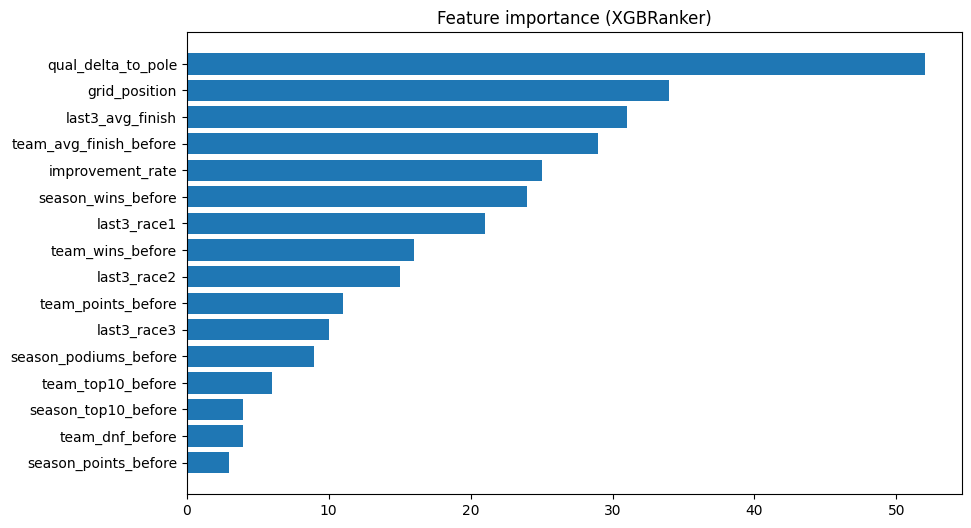

In [22]:
importance = ranker.get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'score': list(importance.values())
}).sort_values('score', ascending=False)

print(importance_df)

plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'], importance_df['score'])
plt.gca().invert_yaxis()
plt.title("Feature importance (XGBRanker)")
plt.show()

In [25]:
DATA_PATH_UAE = "/kaggle/input/formula1-2025-uae/f1_2025_UAE.csv"
df_uae = pd.read_csv(DATA_PATH_UAE)

#must compute race id with year and round number 
df_uae['race_id'] = df_uae['year'].astype(str) + "_" + df_uae['round'].astype(str) + "_" + df_uae['race_name'].str.replace(" ", "_")
df_uae[numeric_cols] = df_uae[numeric_cols].fillna(df_train[numeric_cols].median())

X_uae = df_uae[feature_cols]

loaded_ranker = xgb.XGBRanker()
loaded_ranker.load_model("xgboost_ranker.json")

df_uae['pred_score'] = loaded_ranker.predict(X_uae)
df_uae['driver_name'] = df_uae['driver']

top3_uae = df_uae.groupby('race_id').apply(
    lambda g: g.sort_values('pred_score', ascending=False).head(3)
).reset_index(drop=True)

print("\n=== Top‑3 predictions for 2025 UAE races ===")
for race_id, grp in top3_uae.groupby('race_id'):
    print(f"Race: {race_id}")
    for i, r in enumerate(grp.itertuples(), 1):
        print(f"  Predicted {i:>2}: {r.driver_name:20s}  score = {r.pred_score:.3f}")
    print("-"*60)


=== Top‑3 predictions for 2025 UAE races ===
Race: 2025_24_United_Arab_Emirates_GP
  Predicted  1: Lando Norris          score = 0.023
  Predicted  2: MAX VERSTAPPEN        score = 0.013
  Predicted  3: Oscar Piastri         score = 0.011
------------------------------------------------------------


/tmp/ipykernel_47/2412791607.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_uae = df_uae.groupby('race_id').apply(
